In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
from math import exp, log

In [3]:
N = 300

def rhs(t, F, params):
    """
    Right-hand side for the system F0..F8.
    F is ordered [F0, F1, F2, F3, F4, F5, F6, F7, F8].
    params is a dict containing: k_avg, lam1, lam2, mu, mu_bar
    """
    k = params['k_avg']
    lam1 = params['lam1']
    lam2 = params['lam2']
    mu = params['mu']
    mu_bar = params['mu_bar']
    
    F0, F1, F2, F3, F4, F5, F6, F7, F8 = F

    # common combinations
    comb1 = F1 + F4 + F7
    comb2 = F3 + F4 + F5

    dF0 = -k * lam1 * F0 * comb1 - k * lam2 * F0 * comb2
    dF1 = -F1 * mu - k * lam2 * F1 * comb2 + k * lam1 * F0 * comb1
    dF2 = F1 * mu - k * F2 * lam2 * comb2
    dF3 = -k * lam1 * F3 * comb1 - F3 * mu + k * lam2 * F0 * comb2
    dF4 = k * lam1 * F3 * comb1 + k * lam2 * F1 * comb2 - F4 * mu_bar
    dF5 = k * lam2 * F2 * comb2 - F5 * mu
    dF6 = -k * lam1 * F6 * comb1 + F3 * mu
    dF7 = k * lam1 * F6 * comb1 - F7 * mu
    dF8 = F4 * mu_bar + F7 * mu + F5 * mu

    return [dF0, dF1, dF2, dF3, dF4, dF5, dF6, dF7, dF8]


# --- Initial conditions (placeholders a,b,c,... fill these) ---
# Order: F0, F1, F2, F3, F4, F5, F6, F7, F8
y0 = [(N-2)/N, 1/N, 0, 1/N, 0, 0, 0, 0, 0]  

# --- Time span and evaluation times ---
t_span = (0.0, 50.0)               # start and end time
t_eval = np.linspace(t_span[0], t_span[1], 501)


In [4]:
L = 0.25
# --- Parameters  ---
params = {
    'k_avg': 10,    # <k>
    'lam1': L,     # lambda_1
    'lam2': L,     # lambda_2
    'mu': 1.0,       # mu
    'mu_bar': 1.0    # \bar{\mu}
}

mu_bar = params['mu_bar']

In [5]:
# --- Solve ---
sol = solve_ivp(lambda t, y: rhs(t, y, params),
                t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)

# Check success
if not sol.success:
    raise RuntimeError("ODE solver failed: " + sol.message)

In [6]:
i_A = sol.y[1] + sol.y[4] + sol.y[7]
i_B = sol.y[3] + sol.y[4] + sol.y[5]
J = i_A + i_B - sol.y[4]

In [7]:
c = sol.y[4]

In [8]:
def epidemic_duration(t, J, eps=0.0001):
    # define duration as first time after peak where J < eps
    t_peak_idx = np.argmax(J)
    J_tail = J[t_peak_idx:]
    t_tail = t[t_peak_idx:]

    below = np.where(J_tail < eps)[0]
    if len(below) == 0:
        return np.nan
    return t_tail[below[0]]

In [9]:
def bound(t, C, mub, eps=0.0001):
    idx = np.where(c > eps)[0][0]
    t0 = t[idx]
    c_t0 = C[idx]
    return (t0 + (1/mub)*log((c_t0)/eps))

In [10]:
B = []

In [11]:
mu_bar_range = np.linspace(.1, 1, 100)

In [12]:
L = .25
for m in mu_bar_range:
    params = {
        'k_avg': 10,    # <k>
        'lam1': L,     # lambda_1
        'lam2': L,     # lambda_2
        'mu': 1.0,       # mu
        'mu_bar': m    # \bar{\mu}
        }

    sol = solve_ivp(lambda t, y: rhs(t, y, params),
                t_span, y0, t_eval=t_eval, method='RK45', atol=1e-8, rtol=1e-6)

    # Check success
    if not sol.success:
        raise RuntimeError("ODE solver failed: " + sol.message)

    i_A = sol.y[1] + sol.y[4] + sol.y[7]
    i_B = sol.y[3] + sol.y[4] + sol.y[5]
    J = i_A + i_B - sol.y[4]
    
    c = sol.y[4]
        
    B.append(bound(sol.t, c, m, eps=0.0001))


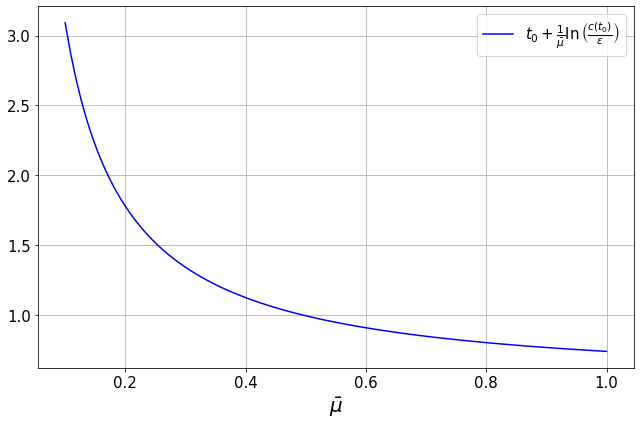

In [13]:
plt.figure(figsize=(9,6))


#plt.plot(mu_bar_range, T_J, 'r', label=r'$T_J (\varepsilon)$')
plt.plot(mu_bar_range, B, 'b', label=r"$t_0 + \frac{1}{\bar{\mu}} \ln\left(\frac{c(t_0)}{\varepsilon}\right)$")

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

plt.xlabel(r"$\bar{\mu}$", fontsize=20)

plt.legend(loc='best', fontsize=15)

plt.grid(True)
plt.tight_layout()

plt.show()